# Ejercicio 4 - Analisis exploratorio con DuckDB

Ocho preguntas sobre los Parquet de 2026, versionadas en
`sql/02_analisis_exploratorio.sql`. Cada celda muestra la pregunta (4.1), su
justificacion, la consulta (4.2/4.3) y el resultado; despues se explica (4.4).

Se conservan los registros originales: cuando una metrica exige viajes plausibles, la
consulta aplica y muestra sus filtros.

In [1]:
from lab_utils import conectar, ejecutar
import matplotlib.pyplot as plt

con = conectar()

In [2]:
resultados = {}

## Comportamiento temporal

**Evolucion mensual de la demanda** (`02_analisis_exploratorio.sql` - `01_evolucion_mensual`)

- **Pregunta:** Como cambia la cantidad de viajes y la facturacion mensual por tipo de taxi?
- **Justificacion:** Permite detectar estacionalidad y comprobar si los dos servicios evolucionan de forma similar.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** Los meses deben compararse tambien por promedio diario porque agosto es el ultimo mes disponible al ejecutar este analisis.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, tpep_pickup_datetime AS pickup_datetime, total_amount
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', lpep_pickup_datetime, total_amount
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
)
SELECT tipo_taxi, month(pickup_datetime) AS mes, count(*) AS viajes,
       round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)), 1) AS viajes_por_dia,
       round(sum(CASE WHEN total_amount >= 0 THEN total_amount ELSE 0 END), 2) AS monto_total
FROM viajes
WHERE pickup_datetime >= DATE '2026-01-01' AND pickup_datetime < DATE '2027-01-01'
GROUP BY tipo_taxi, mes
ORDER BY mes, tipo_taxi;
```

,tipo_taxi,mes,viajes,viajes_por_dia,monto_total
0,green,1,40258,"1,298.60","975,384.51"
1,yellow,1,3724894,"120,157.90","109,900,325.03"
2,green,2,37388,"1,335.30","908,060.17"
3,yellow,2,3399866,"121,423.80","103,185,180.49"
4,green,3,44203,"1,425.90","1,102,634.62"
5,yellow,3,3952443,"127,498.20","119,556,614.46"
6,green,4,44243,"1,474.80","1,126,174.26"
7,yellow,4,3831256,"127,708.50","115,359,372.94"
8,green,5,44925,"1,449.20","1,166,887.18"
9,yellow,5,4090824,"131,962.10","125,127,294.80"


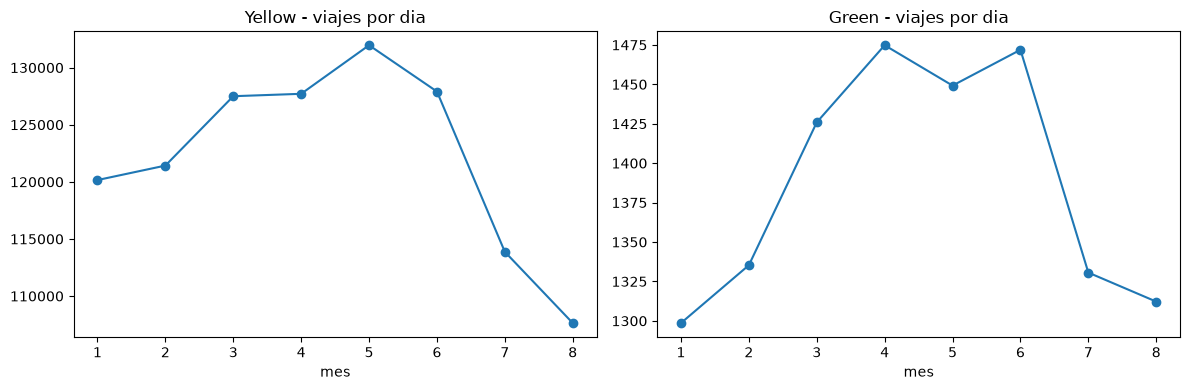

In [3]:
df = resultados["01_evolucion_mensual"] = ejecutar(con, "02_analisis_exploratorio.sql", "01_evolucion_mensual")
display(df)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, tipo in enumerate(("yellow", "green")):
    d = df[df.tipo_taxi == tipo]
    ax[i].plot(d.mes, d.viajes_por_dia, marker="o")
    ax[i].set(title=f"{tipo.capitalize()} - viajes por dia", xlabel="mes")
plt.tight_layout()

**Patron por hora y tipo de dia** (`02_analisis_exploratorio.sql` - `02_patron_horario`)

- **Pregunta:** En que horas se concentra la demanda entre dias laborales y fines de semana?
- **Justificacion:** La hora y el tipo de dia muestran patrones operativos que el total mensual oculta.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** Se reporta la participacion dentro de cada tipo de taxi para hacer comparables sus escalas muy diferentes.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, tpep_pickup_datetime AS pickup_datetime
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', lpep_pickup_datetime
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
), resumen AS (
    SELECT tipo_taxi,
           CASE WHEN dayofweek(pickup_datetime) IN (0, 6) THEN 'fin_semana' ELSE 'laboral' END AS tipo_dia,
           hour(pickup_datetime) AS hora, count(*) AS viajes
    FROM viajes
    WHERE pickup_datetime >= DATE '2026-01-01' AND pickup_datetime < DATE '2027-01-01'
    GROUP BY ALL
)
SELECT *, round(100.0 * viajes / sum(viajes) OVER (PARTITION BY tipo_taxi, tipo_dia), 2) AS porcentaje
FROM resumen
ORDER BY tipo_taxi, tipo_dia, hora;
```

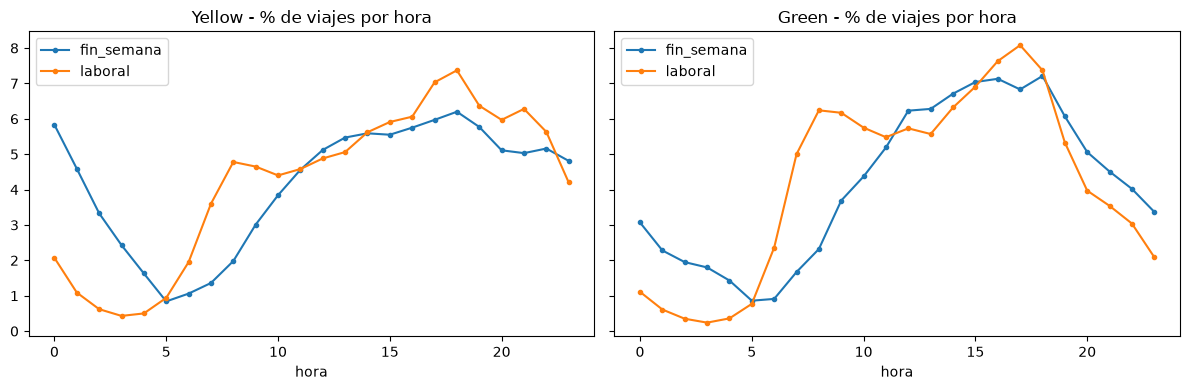

In [4]:
df = resultados["02_patron_horario"] = ejecutar(con, "02_analisis_exploratorio.sql", "02_patron_horario")

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, tipo in enumerate(("yellow", "green")):
    for tipo_dia, d in df[df.tipo_taxi == tipo].groupby("tipo_dia"):
        ax[i].plot(d.hora, d.porcentaje, marker=".", label=tipo_dia)
    ax[i].set(title=f"{tipo.capitalize()} - % de viajes por hora", xlabel="hora")
    ax[i].legend()
plt.tight_layout()

Se usa el porcentaje dentro de cada tipo de taxi porque sus escalas son muy distintas.
Los dias laborales tienen un pico matutino (7-9 h) y el maximo por la tarde (17-18 h).
Los fines de semana no tienen pico matutino, la demanda se reparte entre el mediodia y
la tarde, y la proporcion de viajes entre la medianoche y las 3 h es dos a tres veces
mayor que en dias laborales.

## Caracteristicas de los viajes y diferencias Yellow/Green

In [5]:
resultados["03_caracteristicas_por_tipo"] = ejecutar(con, "02_analisis_exploratorio.sql", "03_caracteristicas_por_tipo")
resultados["03_caracteristicas_por_tipo"]

**Caracteristicas de los viajes por tipo de taxi** (`02_analisis_exploratorio.sql` - `03_caracteristicas_por_tipo`)

- **Pregunta:** Que diferencias existen en distancia, duracion, pasajeros y monto entre Yellow y Green Taxi?
- **Justificacion:** Resume las variables operativas principales usando solo viajes plausibles.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** La media se acompana con la mediana para reducir el efecto de valores extremos.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, tpep_pickup_datetime AS pickup_datetime,
           tpep_dropoff_datetime AS dropoff_datetime, passenger_count, trip_distance, total_amount
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', lpep_pickup_datetime, lpep_dropoff_datetime, passenger_count, trip_distance, total_amount
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
), validos AS (
    SELECT *, date_diff('second', pickup_datetime, dropoff_datetime) / 60.0 AS duracion_min
    FROM viajes
    WHERE pickup_datetime >= DATE '2026-01-01' AND pickup_datetime < DATE '2027-01-01'
      AND dropoff_datetime >= pickup_datetime AND trip_distance > 0 AND total_amount >= 0
)
SELECT tipo_taxi, count(*) AS viajes_validos,
       round(avg(trip_distance), 2) AS distancia_media,
       round(median(trip_distance), 2) AS distancia_mediana,
       round(avg(duracion_min), 2) AS duracion_media_min,
       round(median(duracion_min), 2) AS duracion_mediana_min,
       round(avg(passenger_count), 2) AS pasajeros_promedio,
       round(avg(total_amount), 2) AS monto_promedio,
       round(median(total_amount), 2) AS monto_mediano
FROM validos GROUP BY tipo_taxi ORDER BY tipo_taxi;
```

,tipo_taxi,viajes_validos,distancia_media,distancia_mediana,duracion_media_min,duracion_mediana_min,pasajeros_promedio,monto_promedio,monto_mediano
0,green,324331,13.87,2.15,21.27,13.35,1.30,25.55,20.52
1,yellow,28604878,5.75,1.92,17.75,13.95,1.25,30.20,23.58


## Variables de pago

**Distribucion de formas de pago** (`02_analisis_exploratorio.sql` - `04_formas_pago`)

- **Pregunta:** Que formas de pago utiliza cada tipo de taxi y que proporcion representan?
- **Justificacion:** El metodo de pago condiciona variables como la propina registrada.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** Los codigos siguen el diccionario TLC; NULL y 0 se conservan como no informados.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, payment_type
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', payment_type
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
), resumen AS (
    SELECT tipo_taxi,
           CASE payment_type WHEN 1 THEN 'tarjeta' WHEN 2 THEN 'efectivo'
             WHEN 3 THEN 'sin_cargo' WHEN 4 THEN 'disputa' WHEN 5 THEN 'desconocido'
             WHEN 6 THEN 'viaje_anulado' ELSE 'no_informado' END AS forma_pago,
           count(*) AS viajes
    FROM viajes GROUP BY ALL
)
SELECT *, round(100.0 * viajes / sum(viajes) OVER (PARTITION BY tipo_taxi), 2) AS porcentaje
FROM resumen ORDER BY tipo_taxi, viajes DESC;
```

,tipo_taxi,forma_pago,viajes,porcentaje
0,green,tarjeta,219980,65.25
1,green,efectivo,65921,19.55
2,green,no_informado,48775,14.47
3,green,sin_cargo,1688,0.50
4,green,disputa,750,0.22
5,yellow,tarjeta,18941008,63.77
6,yellow,no_informado,7716688,25.98
7,yellow,efectivo,2708031,9.12
8,yellow,disputa,239488,0.81
9,yellow,sin_cargo,98138,0.33


<Axes: title={'center': 'Formas de pago (% de viajes)'}, ylabel='forma_pago'>

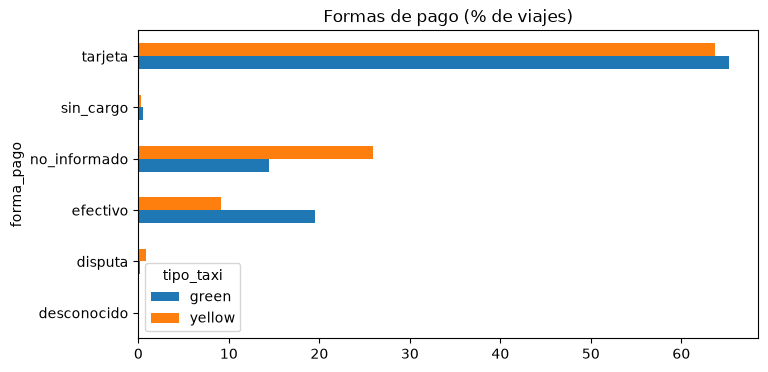

In [6]:
df = resultados["04_formas_pago"] = ejecutar(con, "02_analisis_exploratorio.sql", "04_formas_pago")
display(df)
df.pivot(index="forma_pago", columns="tipo_taxi", values="porcentaje").plot.barh(
    figsize=(8, 4), title="Formas de pago (% de viajes)")

In [7]:
resultados["05_propinas_tarjeta"] = ejecutar(con, "02_analisis_exploratorio.sql", "05_propinas_tarjeta")
resultados["05_propinas_tarjeta"]

**Propinas en pagos con tarjeta** (`02_analisis_exploratorio.sql` - `05_propinas_tarjeta`)

- **Pregunta:** Como difiere la propina registrada entre Yellow y Green Taxi en pagos con tarjeta?
- **Justificacion:** TLC solo registra automaticamente la propina de tarjeta, por lo que restringir el metodo evita una comparacion sesgada.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** La tasa usa fare_amount positivo como denominador y excluye importes negativos.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, fare_amount, tip_amount, payment_type
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', fare_amount, tip_amount, payment_type
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
)
SELECT tipo_taxi, count(*) AS pagos_tarjeta,
       round(avg(tip_amount), 2) AS propina_promedio,
       round(median(tip_amount), 2) AS propina_mediana,
       round(100.0 * avg(CASE WHEN tip_amount > 0 THEN 1 ELSE 0 END), 2) AS pct_con_propina,
       round(100.0 * sum(tip_amount) / sum(fare_amount), 2) AS propina_sobre_tarifa_pct
FROM viajes
WHERE payment_type = 1 AND fare_amount > 0 AND tip_amount >= 0
GROUP BY tipo_taxi ORDER BY tipo_taxi;
```

,tipo_taxi,pagos_tarjeta,propina_promedio,propina_mediana,pct_con_propina,propina_sobre_tarifa_pct
0,green,219842,3.84,3.08,90.45,20.93
1,yellow,18937340,4.28,3.29,91.10,21.53


## Distribucion de valores relevantes

In [8]:
resultados["06_distribucion"] = ejecutar(con, "02_analisis_exploratorio.sql", "06_distribucion")
resultados["06_distribucion"]

**Percentiles de distancia, duracion y monto** (`02_analisis_exploratorio.sql` - `06_distribucion`)

- **Pregunta:** Cual es la distribucion de los valores relevantes y cuanto se aleja la cola superior del viaje tipico?
- **Justificacion:** Los percentiles describen distribuciones asimetricas mejor que unicamente el promedio.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** P99 no define por si mismo un error, pero permite fijar umbrales de revision con evidencia.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, tpep_pickup_datetime AS pickup_datetime, tpep_dropoff_datetime AS dropoff_datetime,
           trip_distance, total_amount
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', lpep_pickup_datetime, lpep_dropoff_datetime, trip_distance, total_amount
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
), validos AS (
    SELECT *, date_diff('second', pickup_datetime, dropoff_datetime) / 60.0 AS duracion_min
    FROM viajes WHERE dropoff_datetime >= pickup_datetime AND trip_distance > 0 AND total_amount >= 0
      AND pickup_datetime >= DATE '2026-01-01' AND pickup_datetime < DATE '2027-01-01'
)
SELECT tipo_taxi, variable, round(p50, 2) AS p50, round(p90, 2) AS p90,
       round(p95, 2) AS p95, round(p99, 2) AS p99, round(maximo, 2) AS maximo
FROM (
    SELECT tipo_taxi, 'distancia_millas' AS variable, approx_quantile(trip_distance, .5) AS p50,
           approx_quantile(trip_distance, .9) AS p90, approx_quantile(trip_distance, .95) AS p95,
           approx_quantile(trip_distance, .99) AS p99, max(trip_distance) AS maximo FROM validos GROUP BY tipo_taxi
    UNION ALL
    SELECT tipo_taxi, 'duracion_min', approx_quantile(duracion_min, .5), approx_quantile(duracion_min, .9),
           approx_quantile(duracion_min, .95), approx_quantile(duracion_min, .99), max(duracion_min) FROM validos GROUP BY tipo_taxi
    UNION ALL
    SELECT tipo_taxi, 'monto_usd', approx_quantile(total_amount, .5), approx_quantile(total_amount, .9),
           approx_quantile(total_amount, .95), approx_quantile(total_amount, .99), max(total_amount) FROM validos GROUP BY tipo_taxi
) ORDER BY tipo_taxi, variable;
```

,tipo_taxi,variable,p50,p90,p95,p99,maximo
0,green,distancia_millas,2.15,7.55,10.70,17.95,"179,830.92"
1,green,duracion_min,13.35,33.15,45.20,84.51,"1,638.28"
2,green,monto_usd,20.55,44.87,56.96,96.11,"1,678.20"
3,yellow,distancia_millas,1.92,8.68,12.64,19.61,"328,522.20"
4,yellow,duracion_min,13.97,33.32,43.85,71.65,"17,165.42"
5,yellow,monto_usd,23.55,54.59,77.34,105.17,"7,053.50"


La distancia mediana ronda 2 millas, pero el maximo es varios ordenes de magnitud
mayor: las distribuciones son muy asimetricas, por eso se reportan percentiles.

## Valores atipicos e inconsistencias

In [9]:
resultados["07_atipicos_inconsistencias"] = ejecutar(con, "02_analisis_exploratorio.sql", "07_atipicos_inconsistencias")
resultados["07_atipicos_inconsistencias"]

**Valores atipicos e inconsistencias** (`02_analisis_exploratorio.sql` - `07_atipicos_inconsistencias`)

- **Pregunta:** Cuantos registros presentan valores imposibles o extremos que requieren revision?
- **Justificacion:** Cuantificar cada regla evita eliminar datos silenciosamente y muestra su impacto por servicio.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** Los umbrales de 100 millas, 6 horas y USD 500 son banderas de revision, no pruebas automaticas de error.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, tpep_pickup_datetime AS pickup_datetime, tpep_dropoff_datetime AS dropoff_datetime,
           passenger_count, trip_distance, fare_amount, total_amount
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', lpep_pickup_datetime, lpep_dropoff_datetime, passenger_count, trip_distance, fare_amount, total_amount
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
)
SELECT tipo_taxi, count(*) AS registros,
       count_if(dropoff_datetime < pickup_datetime) AS duracion_negativa,
       count_if(date_diff('hour', pickup_datetime, dropoff_datetime) > 6) AS duracion_mayor_6h,
       count_if(trip_distance <= 0) AS distancia_no_positiva,
       count_if(trip_distance > 100) AS distancia_mayor_100mi,
       count_if(passenger_count <= 0) AS pasajeros_no_positivos,
       count_if(passenger_count > 8) AS pasajeros_mayor_8,
       count_if(fare_amount < 0) AS tarifa_negativa,
       count_if(total_amount < 0) AS total_negativo,
       count_if(total_amount > 500) AS total_mayor_500
FROM viajes
WHERE pickup_datetime >= DATE '2026-01-01' AND pickup_datetime < DATE '2027-01-01'
GROUP BY tipo_taxi ORDER BY tipo_taxi;
```

,tipo_taxi,registros,duracion_negativa,duracion_mayor_6h,distancia_no_positiva,distancia_mayor_100mi,pasajeros_no_positivos,pasajeros_mayor_8,tarifa_negativa,total_negativo,total_mayor_500
0,green,337100,5,1089,12208,72,4527,31,999,1023,21
1,yellow,29703338,10,7101,952231,1223,91359,6,157363,161834,791


## Rutas mas frecuentes

In [10]:
resultados["08_rutas_frecuentes"] = ejecutar(con, "02_analisis_exploratorio.sql", "08_rutas_frecuentes")
resultados["08_rutas_frecuentes"]

**Rutas mas frecuentes** (`02_analisis_exploratorio.sql` - `08_rutas_frecuentes`)

- **Pregunta:** Cuales son los pares de zonas de origen y destino con mayor volumen en cada servicio?
- **Justificacion:** Las rutas frecuentes describen la geografia operativa sin requerir cargar geometria espacial.
- **Fuente:** Archivos Parquet Yellow y Green Taxi de 2026.
- **Interpretacion:** Se muestran identificadores TLC de zona; pueden unirse posteriormente al Taxi Zone Lookup.

```sql
WITH viajes AS (
    SELECT 'yellow' AS tipo_taxi, PULocationID AS origen, DOLocationID AS destino
    FROM read_parquet('data/raw/yellow/2026/*.parquet', union_by_name = true)
    UNION ALL
    SELECT 'green', PULocationID, DOLocationID
    FROM read_parquet('data/raw/green/2026/*.parquet', union_by_name = true)
), rutas AS (
    SELECT tipo_taxi, origen, destino, count(*) AS viajes
    FROM viajes WHERE origen IS NOT NULL AND destino IS NOT NULL GROUP BY ALL
)
SELECT tipo_taxi, origen, destino, viajes
FROM rutas QUALIFY row_number() OVER (PARTITION BY tipo_taxi ORDER BY viajes DESC) <= 10
ORDER BY tipo_taxi, viajes DESC;
```

,tipo_taxi,origen,destino,viajes
0,green,74,75,14016
1,green,74,236,10323
2,green,75,74,7367
3,green,74,166,6150
4,green,95,95,5473
5,green,74,263,5171
6,green,74,238,5138
7,green,74,41,4715
8,green,74,74,4222
9,green,74,42,3890


## 4.5. Hallazgos relevantes

Los hallazgos se calculan a partir de los resultados anteriores con la misma funcion
que usa `scripts/run_eda.py`, de modo que se actualizan si cambian los datos.

In [11]:
from run_eda import generar_hallazgos

tuplas = {k: (list(v.columns), list(v.itertuples(index=False, name=None))) for k, v in resultados.items()}
for hallazgo in generar_hallazgos(tuplas):
    print("-", hallazgo)

- La mayor demanda diaria de Yellow ocurre en el mes 5: 131,962.1 viajes por dia.
- La mayor demanda diaria de Green ocurre en el mes 4: 1,474.8 viajes por dia.
- En dias laborales, la hora pico de Yellow es las 18:00 (7.37% de sus viajes laborales).
- En dias laborales, la hora pico de Green es las 17:00 (8.08% de sus viajes laborales).
- El viaje mediano de Yellow recorre 1.92 millas y cuesta USD 23.58; en Green las medianas son 2.15 millas y USD 20.52.
- En pagos con tarjeta de Green, 90.45% registra propina y la mediana es USD 3.08.
- En pagos con tarjeta de Yellow, 91.10% registra propina y la mediana es USD 3.29.
- En Yellow, la categoria de pago mas frecuente es tarjeta (63.77% de los viajes).
- En Green, la categoria de pago mas frecuente es tarjeta (65.25% de los viajes).
- La calidad requiere filtros explicitos: 964,439 de 30,040,438 registros tienen distancia no positiva y 162,857 tienen monto total negativo.
